# Bigger model

In [1]:
ML_DATA_TRAIN_PATH = './../data/final_data_2/ml_final_data_train.csv'
ML_DATA_VAL_PATH = './../data/final_data_2/ml_final_data_val.csv'
ML_DATA_TEST_PATH = './../data/final_data_2/ml_final_data_test.csv'
MODEL_PATH = "./../stored_models/model_6_multiple_losses.h5"
HISTORY_PATH = './../stored_models/history_6_multiple_losses.json'
STEP_PATH = './../stored_models/history_step_6_multiple_losses.json'
import sqlite3
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.python.client import device_lib
import os
import sys
from collections import Counter
from keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, Input, BatchNormalization, Activation, Add, LeakyReLU, Concatenate, Multiply
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras import layers
from tensorflow.keras.applications import InceptionResNetV2, VGG16, MobileNetV2
from tensorflow.keras.utils import to_categorical
from PIL import Image
import requests
import zipfile

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output as cls
from keras.callbacks import EarlyStopping, ModelCheckpoint, LearningRateScheduler
import pandas as pd
import PIL

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from pathlib import Path
import statistics
import ast
import json
import statistics

import glob
import cv2
from PIL import Image
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight

module_path = os.path.abspath(os.path.join('..', 'utils'))
if module_path not in sys.path:
    sys.path.append(module_path)

from utils2 import DataGenerator, plot_graph, bar_plot, two_bar_plot, StepwiseLogger

In [44]:
read_size = 524288
batch_size = 64
num_classes = 64
train_data_generator = DataGenerator(ML_DATA_TRAIN_PATH, read_size, batch_size, num_classes, 3910783, single_and_partial=True)
val_data_generator = DataGenerator(ML_DATA_VAL_PATH, read_size, batch_size, num_classes, 434532, single_and_partial=True)
test_data_generator = DataGenerator(ML_DATA_TEST_PATH, read_size, batch_size, num_classes, 482813, single_and_partial=True)

In [17]:
def residual_cnn_block(input, filters, kernel, padding):
    cnn = Conv2D(filters, kernel, padding=padding)(input)
    cnn = BatchNormalization()(cnn)
    cnn = LeakyReLU()(cnn)

    cnn = Conv2D(filters, kernel, padding=padding)(cnn)
    cnn = BatchNormalization()(cnn)

    cnn = Add()([input, cnn])
    cnn = LeakyReLU()(cnn)

    return cnn

In [61]:
def create_model(board_shape):
    board_input = Input(shape=board_shape)

    cnn = Conv2D(64, (3, 3), padding='same')(board_input)
    cnn = BatchNormalization()(cnn)
    cnn = LeakyReLU()(cnn)

    cnn = residual_cnn_block(cnn, 64, (3, 3), 'same')
    cnn = residual_cnn_block(cnn, 64, (3, 3), 'same')
    cnn = residual_cnn_block(cnn, 64, (3, 3), 'same')
    cnn = residual_cnn_block(cnn, 64, (3, 3), 'same')

    latent_space = Flatten()(cnn)
    
    mlp_initial_pos = Dense(512, activation='relu')(latent_space)
    mlp_initial_pos = Dropout(0.1)(mlp_initial_pos)
    mlp_initial_pos = Dense(256, activation='relu')(mlp_initial_pos)
    mlp_initial_pos = Dropout(0.1)(mlp_initial_pos)

    initial_pos_preds = Dense(64, activation='sigmoid', name = 'initial_pos')(mlp_initial_pos)

    mlp_final_pos = Dense(512, activation='relu')(latent_space)
    mlp_final_pos = Dropout(0.1)(mlp_final_pos)
    mlp_final_pos = Dense(256, activation='relu')(mlp_final_pos)
    mlp_final_pos = Dropout(0.1)(mlp_final_pos)

    final_pos_preds = Dense(64, activation='sigmoid', name = 'final_pos')(mlp_final_pos)

    move_input = Concatenate()([latent_space, initial_pos_preds, final_pos_preds])

    mlp_move = Dense(512, activation='relu')(move_input)
    mlp_final_pos = Dropout(0.1)(mlp_final_pos)
    mlp_move = Dense(4096, activation='softmax', name = 'full_move')(mlp_move)

    model = Model(inputs=board_input, outputs=[mlp_move, initial_pos_preds, final_pos_preds])
    return model

In [62]:
INPUT_SHAPE = (8, 8, 6)
model = create_model(INPUT_SHAPE)
model.summary()

Model: "model_8"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_9 (InputLayer)           [(None, 8, 8, 6)]    0           []                               
                                                                                                  
 conv2d_72 (Conv2D)             (None, 8, 8, 64)     3520        ['input_9[0][0]']                
                                                                                                  
 batch_normalization_72 (BatchN  (None, 8, 8, 64)    256         ['conv2d_72[0][0]']              
 ormalization)                                                                                    
                                                                                                  
 leaky_re_lu_72 (LeakyReLU)     (None, 8, 8, 64)     0           ['batch_normalization_72[0]

In [63]:
losses = {
    'full_move': 'categorical_crossentropy',
    'initial_pos': 'sparse_categorical_crossentropy',
    'final_pos': 'sparse_categorical_crossentropy'
}

In [64]:
model.compile(optimizer='Adam', loss=losses, metrics='accuracy')
steps_per_epoch_val = len(val_data_generator)
stepwise_logger = StepwiseLogger(val_data_generator, steps_per_epoch_val, 10000, divide=50)

In [65]:
history = model.fit(train_data_generator, epochs=20, validation_data=val_data_generator, shuffle=False, callbacks=[stepwise_logger, ModelCheckpoint(MODEL_PATH, save_best_only=True), EarlyStopping(patience=5, restore_best_weights=True)])

Epoch 1/20
61106/61106 [==============================] - 1260s 20ms/step - loss: 6.3571 - full_move_loss: 2.6296 - initial_pos_loss: 1.5146 - final_pos_loss: 2.2129 - full_move_accuracy: 0.3364 - initial_pos_accuracy: 0.4745 - final_pos_accuracy: 0.3778 - val_loss: 6.0819 - val_full_move_loss: 2.5487 - val_initial_pos_loss: 1.4419 - val_final_pos_loss: 2.0913 - val_full_move_accuracy: 0.3490 - val_initial_pos_accuracy: 0.4838 - val_final_pos_accuracy: 0.3917
Epoch 2/20
61106/61106 [==============================] - 1203s 20ms/step - loss: 5.9060 - full_move_loss: 2.4030 - initial_pos_loss: 1.4415 - final_pos_loss: 2.0615 - full_move_accuracy: 0.3665 - initial_pos_accuracy: 0.4983 - final_pos_accuracy: 0.4013 - val_loss: 5.6321 - val_full_move_loss: 2.3121 - val_initial_pos_loss: 1.3732 - val_final_pos_loss: 1.9468 - val_full_move_accuracy: 0.3793 - val_initial_pos_accuracy: 0.5050 - val_final_pos_accuracy: 0.4140
Epoch 3/20
61106/61106 [==============================] - 1233s 20ms/ste

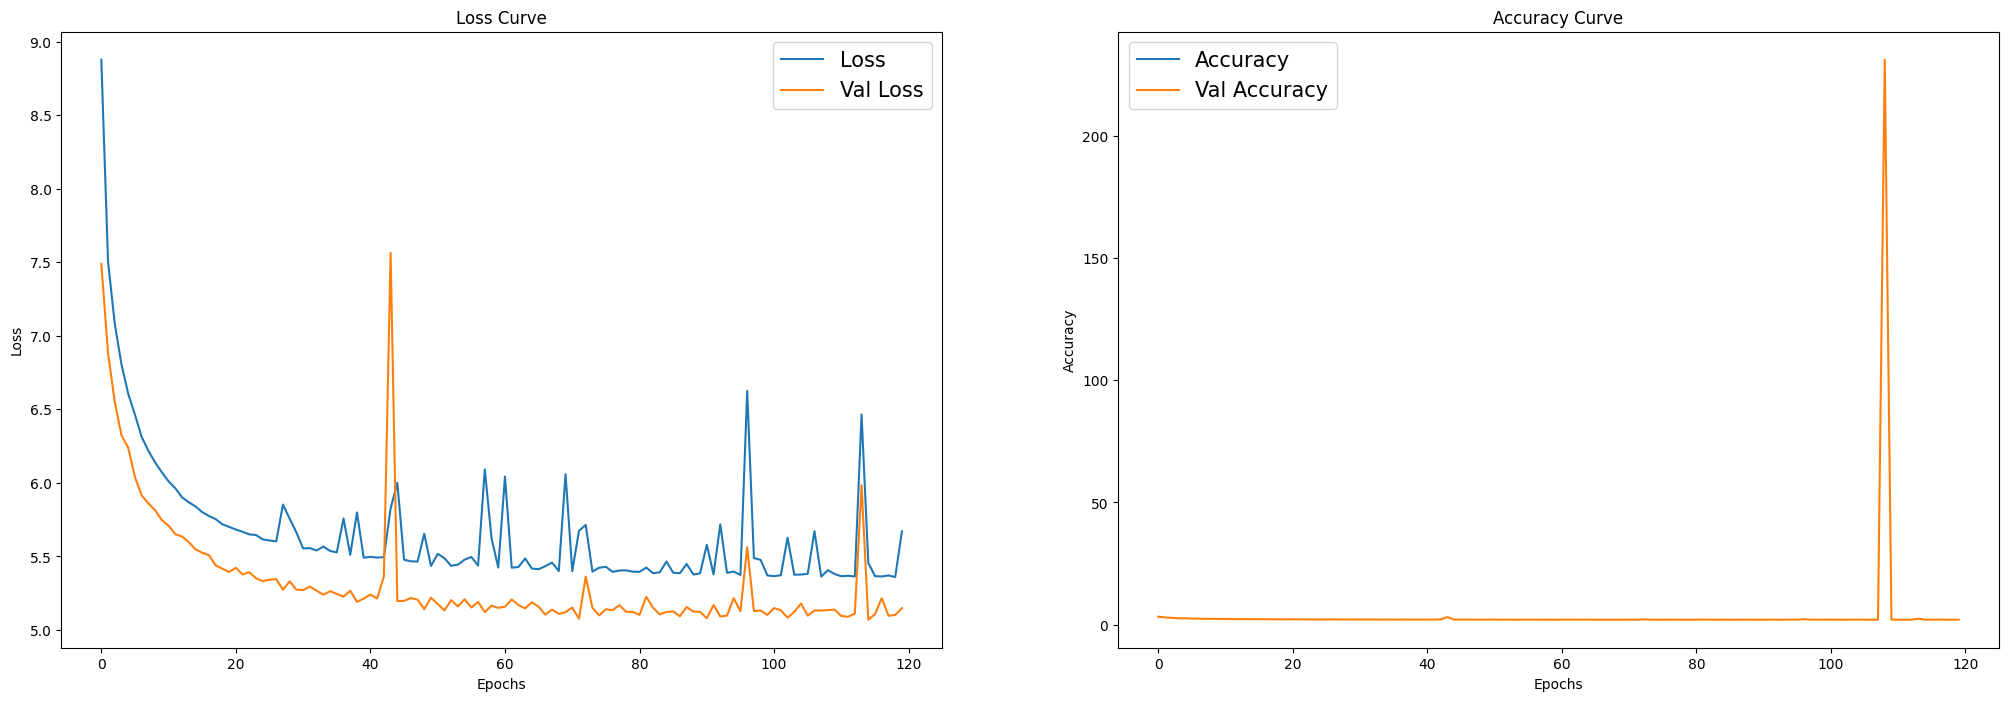

In [85]:
plot_graph(stepwise_logger)

In [87]:
history.history

{'loss': [6.357083320617676,
  5.906026363372803,
  5.699606418609619,
  5.595696449279785,
  5.517730712890625,
  5.486820220947266,
  5.453155994415283,
  5.42644739151001,
  5.4092230796813965,
  5.390989780426025,
  5.397796630859375,
  5.310440540313721,
  5.362044334411621,
  5.360800743103027,
  5.330648899078369,
  5.339728832244873,
  5.33499813079834,
  5.32415771484375,
  6.327788829803467,
  5.3882060050964355],
 'full_move_loss': [2.629617929458618,
  2.402967691421509,
  2.2906875610351562,
  2.2401981353759766,
  2.2044599056243896,
  2.18683123588562,
  2.17268443107605,
  2.162335157394409,
  2.15647029876709,
  2.1512482166290283,
  2.1536178588867188,
  2.119929075241089,
  2.143092632293701,
  2.1417348384857178,
  2.132549524307251,
  2.139514446258545,
  2.138599395751953,
  2.1342854499816895,
  2.5794315338134766,
  2.1629438400268555],
 'initial_pos_loss': [1.5145981311798096,
  1.4415382146835327,
  1.4098318815231323,
  1.3944965600967407,
  1.378941178321838

KeyError: 'accuracy'

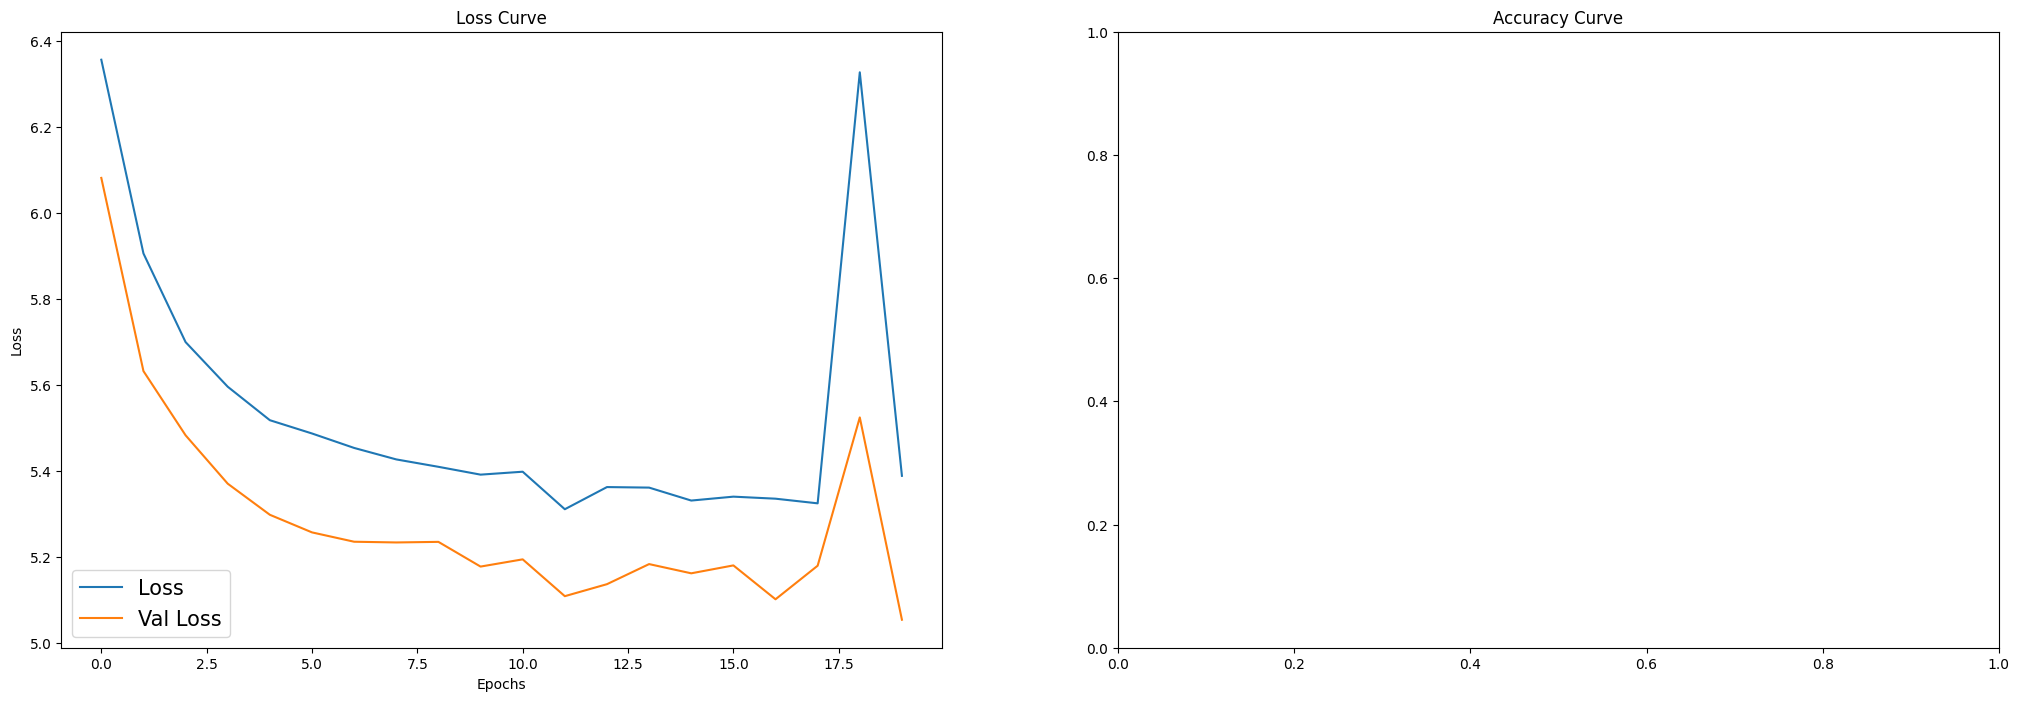

In [86]:
plot_graph(history)

In [88]:
model.evaluate(test_data_generator)

7544/7544 [==============================] - 90s 11ms/step - loss: 5.0515 - full_move_loss: 2.0580 - initial_pos_loss: 1.2690 - final_pos_loss: 1.7246 - full_move_accuracy: 0.4204 - initial_pos_accuracy: 0.5473 - final_pos_accuracy: 0.4610


[5.0515055656433105,
 2.0579946041107178,
 1.2689523696899414,
 1.7245590686798096,
 0.42037808895111084,
 0.5472760796546936,
 0.46099215745925903]

In [91]:
model.save(MODEL_PATH)

In [92]:
with open(HISTORY_PATH, 'w') as file:
    json.dump(history.history, file)

with open(STEP_PATH, 'w') as file:
    json.dump(stepwise_logger.history, file)

# Only one loss

In [12]:
MODEL_PATH = "./../stored_models/model_6_final_pos.h5"
HISTORY_PATH = './../stored_models/history_6_final_pos.json'
STEP_PATH = './../stored_models/history_step_6_final_pos.json'

In [4]:
read_size = 524288
batch_size = 64
num_classes = 64
train_data_generator = DataGenerator(ML_DATA_TRAIN_PATH, read_size, batch_size, num_classes, 3910783, single_move=True)
val_data_generator = DataGenerator(ML_DATA_VAL_PATH, read_size, batch_size, num_classes, 434532, single_move=True)
test_data_generator = DataGenerator(ML_DATA_TEST_PATH, read_size, batch_size, num_classes, 482813, single_move=True)

In [8]:
def create_model_2(board_shape):
    board_input = Input(shape=board_shape)

    cnn = Conv2D(64, (3, 3), padding='same')(board_input)
    cnn = BatchNormalization()(cnn)
    cnn = LeakyReLU()(cnn)

    cnn = residual_cnn_block(cnn, 64, (3, 3), 'same')
    cnn = residual_cnn_block(cnn, 64, (3, 3), 'same')
    cnn = residual_cnn_block(cnn, 64, (3, 3), 'same')
    cnn = residual_cnn_block(cnn, 64, (3, 3), 'same')

    latent_space = Flatten()(cnn)
    
    mlp_initial_pos = Dense(512, activation='relu')(latent_space)
    mlp_initial_pos = Dropout(0.1)(mlp_initial_pos)
    mlp_initial_pos = Dense(256, activation='relu')(mlp_initial_pos)
    mlp_initial_pos = Dropout(0.1)(mlp_initial_pos)

    initial_pos_preds = Dense(64, activation='relu', name = 'initial_pos')(mlp_initial_pos)

    mlp_final_pos = Dense(512, activation='relu')(latent_space)
    mlp_final_pos = Dropout(0.1)(mlp_final_pos)
    mlp_final_pos = Dense(256, activation='relu')(mlp_final_pos)
    mlp_final_pos = Dropout(0.1)(mlp_final_pos)

    final_pos_preds = Dense(64, activation='relu', name = 'final_pos')(mlp_final_pos)

    move_input = Concatenate()([latent_space, initial_pos_preds, final_pos_preds])

    mlp_move = Dense(512, activation='relu')(move_input)
    mlp_final_pos = Dropout(0.1)(mlp_final_pos)
    mlp_move = Dense(4096, activation='softmax', name = 'full_move')(mlp_move)

    model = Model(inputs=board_input, outputs=mlp_move)
    return model

In [6]:
INPUT_SHAPE = (8, 8, 6)
model2 = create_model_2(INPUT_SHAPE)
model2.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 8, 8, 6)]    0           []                               
                                                                                                  
 conv2d (Conv2D)                (None, 8, 8, 64)     3520        ['input_1[0][0]']                
                                                                                                  
 batch_normalization (BatchNorm  (None, 8, 8, 64)    256         ['conv2d[0][0]']                 
 alization)                                                                                       
                                                                                                  
 leaky_re_lu (LeakyReLU)        (None, 8, 8, 64)     0           ['batch_normalization[0][0]']

In [7]:
model2.compile(optimizer='Adam', loss='categorical_crossentropy', metrics='accuracy')
steps_per_epoch_val = len(val_data_generator)
stepwise_logger = StepwiseLogger(val_data_generator, steps_per_epoch_val, 10000, divide=50)

In [8]:
history = model2.fit(train_data_generator, epochs=20, validation_data=val_data_generator, shuffle=False, callbacks=[stepwise_logger, ModelCheckpoint(MODEL_PATH, save_best_only=True), EarlyStopping(patience=5, restore_best_weights=True)])

Epoch 1/20
61106/61106 [==============================] - 1047s 17ms/step - loss: 2.7380 - accuracy: 0.3121 - val_loss: 2.6124 - val_accuracy: 0.3290
Epoch 2/20
61106/61106 [==============================] - 1061s 17ms/step - loss: 2.4826 - accuracy: 0.3487 - val_loss: 2.4005 - val_accuracy: 0.3612
Epoch 3/20
61106/61106 [==============================] - 1072s 17ms/step - loss: 2.3809 - accuracy: 0.3599 - val_loss: 2.3015 - val_accuracy: 0.3756
Epoch 4/20
61106/61106 [==============================] - 1094s 18ms/step - loss: 2.3239 - accuracy: 0.3684 - val_loss: 2.2688 - val_accuracy: 0.3805
Epoch 5/20
61106/61106 [==============================] - 1092s 18ms/step - loss: 2.2966 - accuracy: 0.3756 - val_loss: 2.2218 - val_accuracy: 0.3886
Epoch 6/20
61106/61106 [==============================] - 1111s 18ms/step - loss: 2.2547 - accuracy: 0.3796 - val_loss: 2.1930 - val_accuracy: 0.3908
Epoch 7/20
61106/61106 [==============================] - 1134s 18ms/step - loss: 2.2401 - accuracy:

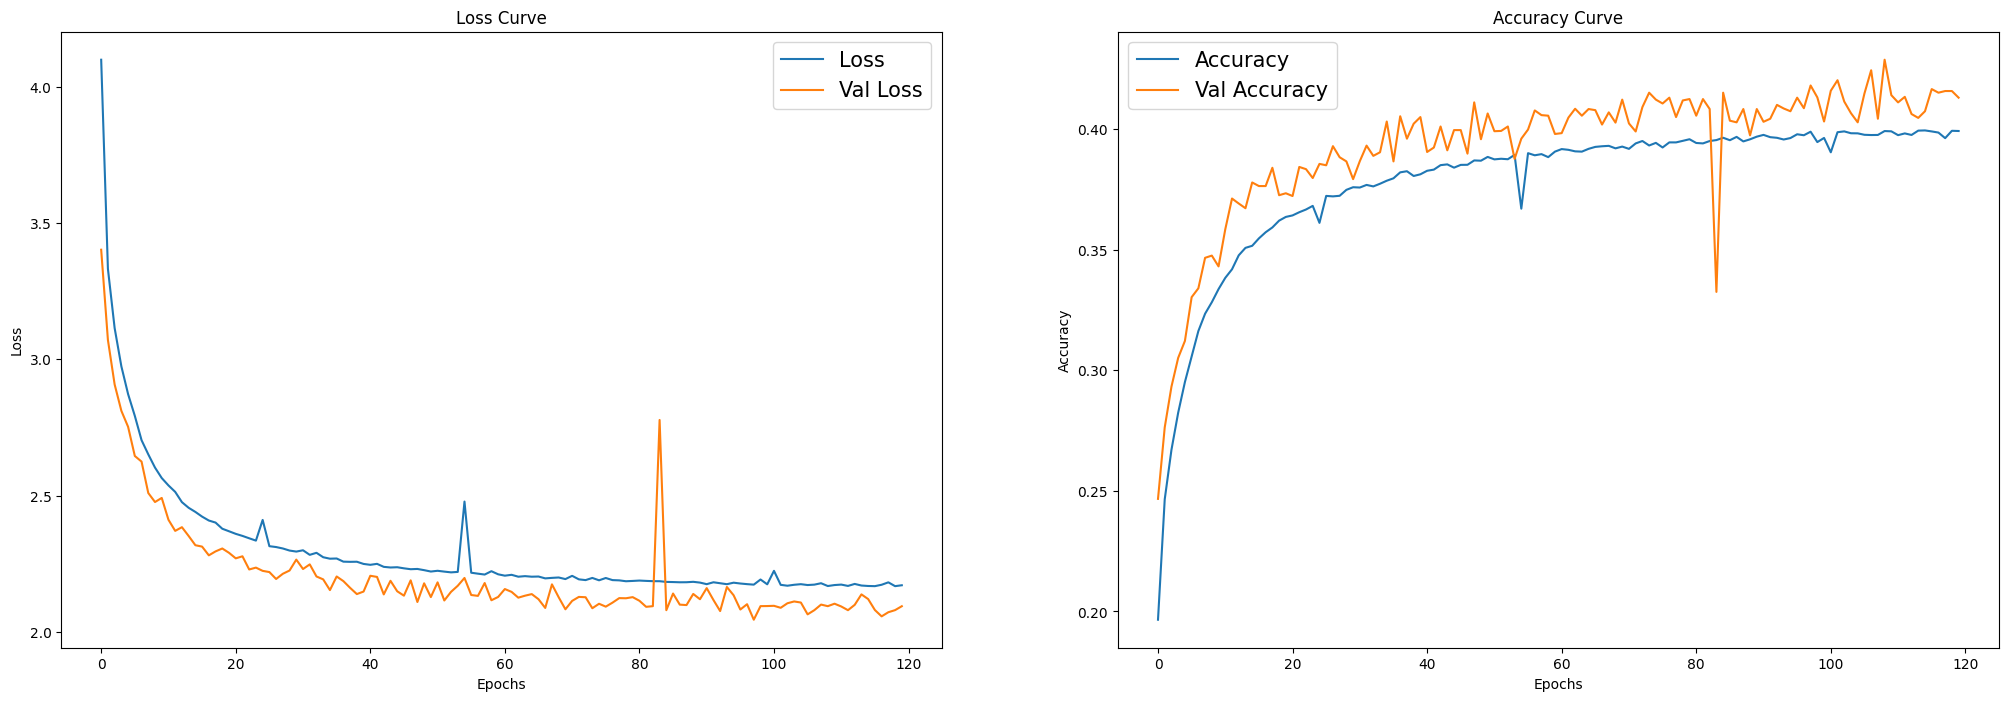

In [10]:
plot_graph(history=stepwise_logger)

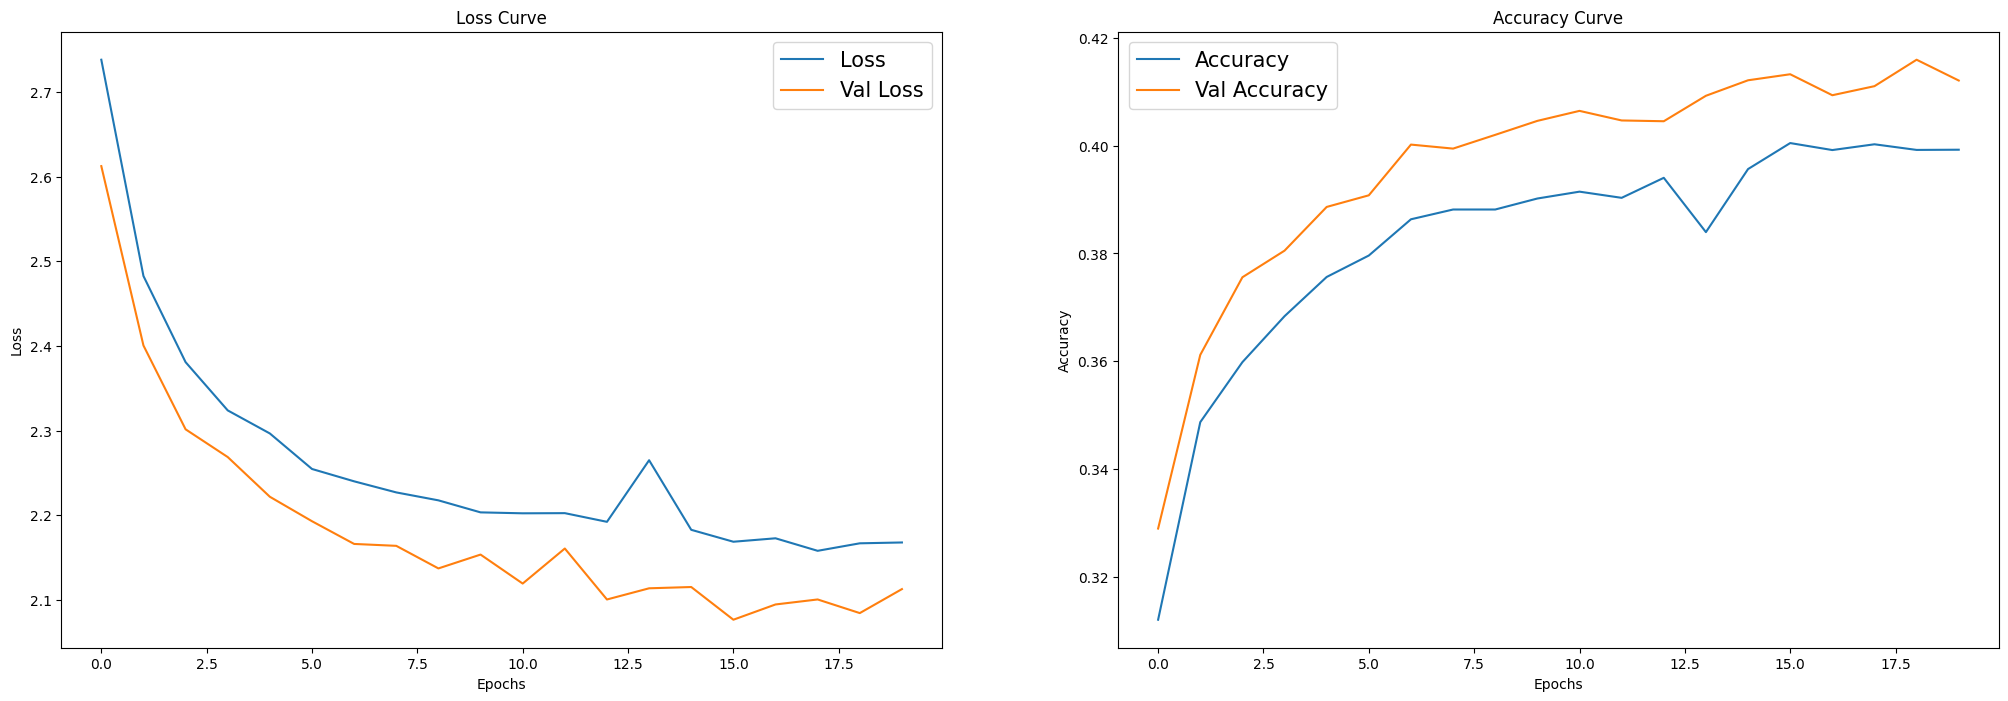

In [11]:
plot_graph(history=history)

In [9]:
model2.evaluate(test_data_generator)

7544/7544 [==============================] - 121s 15ms/step - loss: 2.1110 - accuracy: 0.4120


[2.1109745502471924, 0.41195452213287354]

In [13]:
model2.save(MODEL_PATH)

In [14]:
with open(HISTORY_PATH, 'w') as file:
    json.dump(history.history, file)

with open(STEP_PATH, 'w') as file:
    json.dump(stepwise_logger.history, file)

# Bigger model with losses V2

In [3]:
MODEL_PATH = "./../stored_models/model_6_multiple_losses_V2.h5"
HISTORY_PATH = './../stored_models/history_6_multiple_losses_V2.json'
STEP_PATH = './../stored_models/history_step_6_multiple_losses_V2.json'

In [4]:
read_size = 524288
batch_size = 64
num_classes = 64
train_data_generator = DataGenerator(ML_DATA_TRAIN_PATH, read_size, batch_size, num_classes, 3910783, single_and_partial=True)
val_data_generator = DataGenerator(ML_DATA_VAL_PATH, read_size, batch_size, num_classes, 434532, single_and_partial=True)
test_data_generator = DataGenerator(ML_DATA_TEST_PATH, read_size, batch_size, num_classes, 482813, single_and_partial=True)

In [5]:
def create_model_3(board_shape):
    board_input = Input(shape=board_shape)

    cnn = Conv2D(64, (3, 3), padding='same')(board_input)
    cnn = BatchNormalization()(cnn)
    cnn = LeakyReLU()(cnn)
    cnn = Dropout(0.1)(cnn)

    cnn = residual_cnn_block(cnn, 64, (3, 3), 'same')
    cnn = residual_cnn_block(cnn, 64, (3, 3), 'same')
    cnn = residual_cnn_block(cnn, 64, (3, 3), 'same')
    cnn = residual_cnn_block(cnn, 64, (3, 3), 'same')

    latent_space = Flatten()(cnn)
    
    mlp_initial_pos = Dense(512)(latent_space)
    mlp_initial_pos = BatchNormalization()(mlp_initial_pos)
    mlp_initial_pos = LeakyReLU()(mlp_initial_pos)
    mlp_initial_pos = Dense(256)(mlp_initial_pos)
    mlp_initial_pos = BatchNormalization()(mlp_initial_pos)
    mlp_initial_pos = LeakyReLU()(mlp_initial_pos)
    mlp_initial_pos = Dense(64)(mlp_initial_pos)
    mlp_initial_pos = BatchNormalization()(mlp_initial_pos)
    mlp_initial_pos = LeakyReLU()(mlp_initial_pos)

    initial_pos_preds = Dense(64, activation='sigmoid', name = 'initial_pos')(mlp_initial_pos)

    mlp_final_pos = Dense(512)(latent_space)
    mlp_final_pos = BatchNormalization()(mlp_final_pos)
    mlp_final_pos = LeakyReLU()(mlp_final_pos)
    mlp_final_pos = Dense(256)(mlp_final_pos)
    mlp_final_pos = BatchNormalization()(mlp_final_pos)
    mlp_final_pos = LeakyReLU()(mlp_final_pos)
    mlp_final_pos = Dense(64)(mlp_final_pos)
    mlp_final_pos = BatchNormalization()(mlp_final_pos)
    mlp_final_pos = LeakyReLU()(mlp_final_pos)

    final_pos_preds = Dense(64, activation='sigmoid', name = 'final_pos')(mlp_final_pos)

    move_input = Concatenate()([latent_space, mlp_initial_pos, mlp_final_pos])

    mlp_move = Dense(512)(move_input)
    mlp_move = BatchNormalization()(mlp_move)
    mlp_move = LeakyReLU()(mlp_move)

    mlp_move = Dense(4096, activation='softmax', name = 'full_move')(mlp_move)

    model = Model(inputs=board_input, outputs=[mlp_move, initial_pos_preds, final_pos_preds])
    return model

In [6]:
INPUT_SHAPE = (8, 8, 6)
model3 = create_model_3(INPUT_SHAPE)
model3.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 8, 8, 6)]    0           []                               
                                                                                                  
 conv2d (Conv2D)                (None, 8, 8, 64)     3520        ['input_1[0][0]']                
                                                                                                  
 batch_normalization (BatchNorm  (None, 8, 8, 64)    256         ['conv2d[0][0]']                 
 alization)                                                                                       
                                                                                                  
 leaky_re_lu (LeakyReLU)        (None, 8, 8, 64)     0           ['batch_normalization[0][0]']

In [7]:
losses = {
    'full_move': 'categorical_crossentropy',
    'initial_pos': 'sparse_categorical_crossentropy',
    'final_pos': 'sparse_categorical_crossentropy'
}

In [8]:
model3.compile(optimizer='Adam', loss=losses, metrics='accuracy')
steps_per_epoch_val = len(val_data_generator)
stepwise_logger = StepwiseLogger(val_data_generator, steps_per_epoch_val, 10000, divide=50)

In [9]:
history = model3.fit(train_data_generator, epochs=20, validation_data=val_data_generator, shuffle=False, callbacks=[stepwise_logger, ModelCheckpoint(MODEL_PATH, save_best_only=True), EarlyStopping(patience=5, restore_best_weights=True)])

Epoch 1/20
61106/61106 [==============================] - 1340s 22ms/step - loss: 5.4778 - full_move_loss: 2.1543 - initial_pos_loss: 1.3918 - final_pos_loss: 1.9316 - full_move_accuracy: 0.3915 - initial_pos_accuracy: 0.5074 - final_pos_accuracy: 0.4218 - val_loss: 5.3443 - val_full_move_loss: 2.0992 - val_initial_pos_loss: 1.3590 - val_final_pos_loss: 1.8861 - val_full_move_accuracy: 0.3999 - val_initial_pos_accuracy: 0.5203 - val_final_pos_accuracy: 0.4293
Epoch 2/20
61106/61106 [==============================] - 1338s 22ms/step - loss: 5.0902 - full_move_loss: 1.9768 - initial_pos_loss: 1.3134 - final_pos_loss: 1.8001 - full_move_accuracy: 0.4233 - initial_pos_accuracy: 0.5330 - final_pos_accuracy: 0.4471 - val_loss: 5.0495 - val_full_move_loss: 1.9774 - val_initial_pos_loss: 1.2943 - val_final_pos_loss: 1.7778 - val_full_move_accuracy: 0.4218 - val_initial_pos_accuracy: 0.5400 - val_final_pos_accuracy: 0.4497
Epoch 3/20
61106/61106 [==============================] - 1352s 22ms/ste

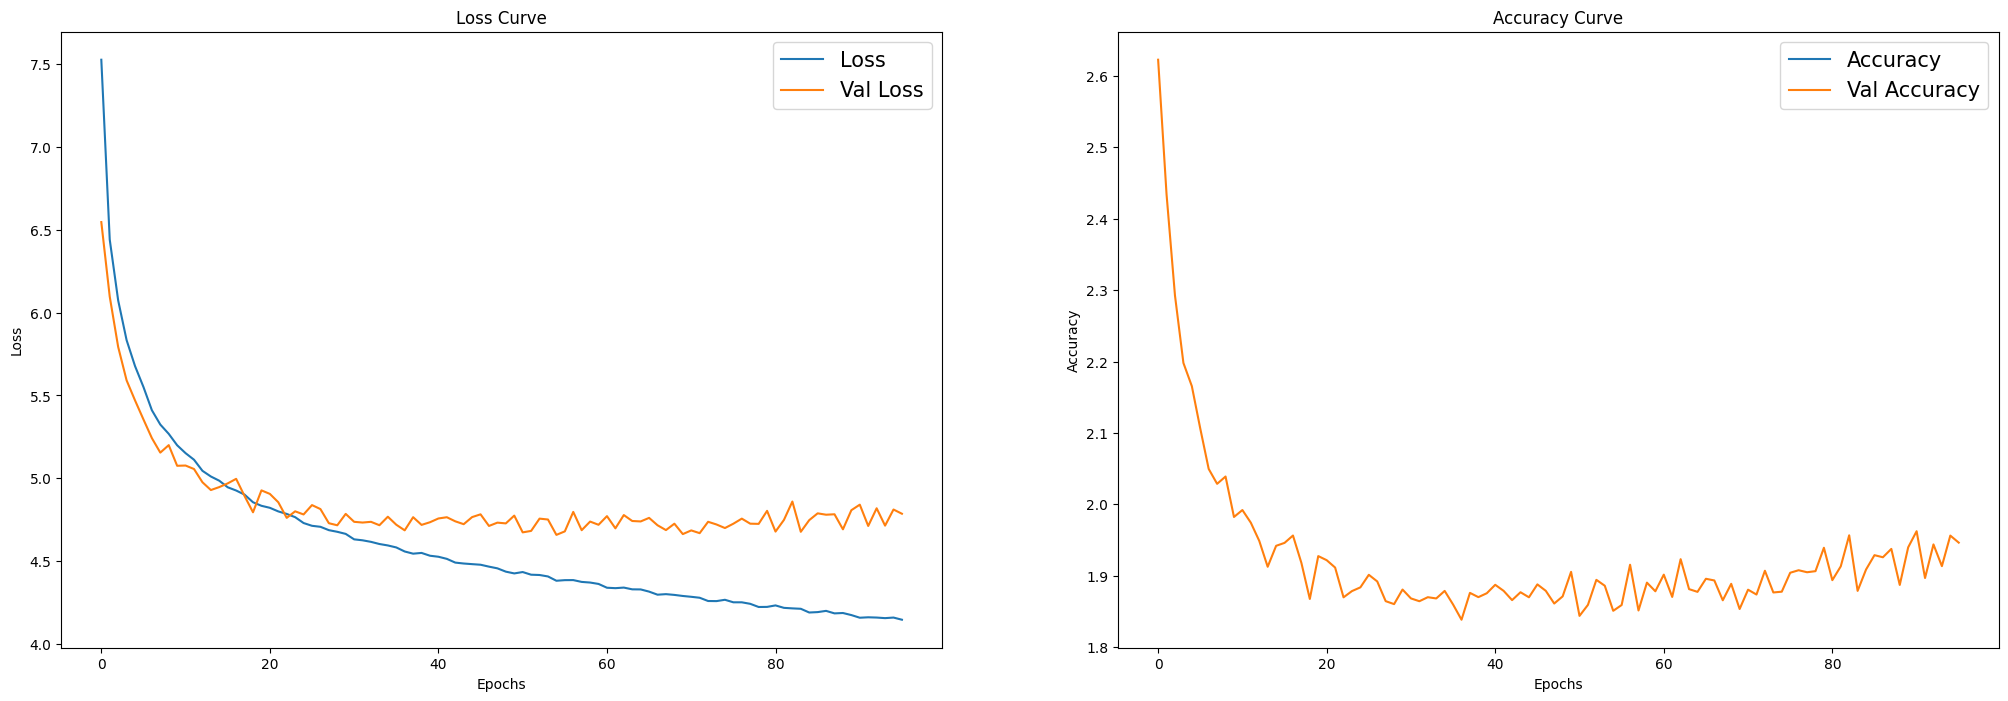

In [11]:
plot_graph(history=stepwise_logger)

KeyError: 'accuracy'

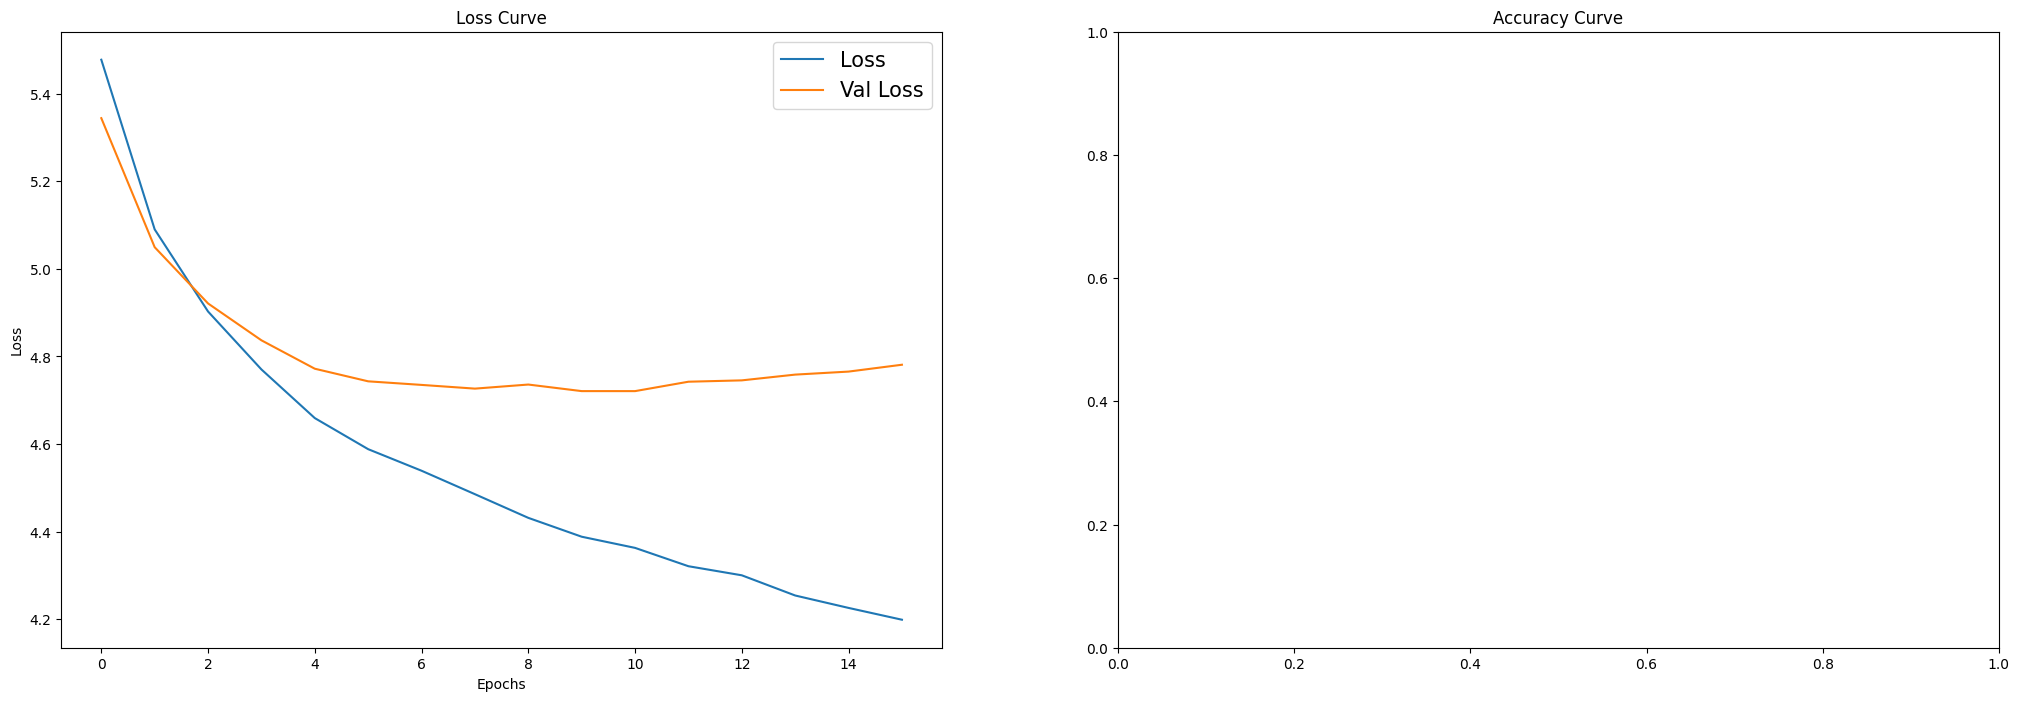

In [12]:
plot_graph(history=history)

In [10]:
model3.evaluate(test_data_generator)

7544/7544 [==============================] - 114s 14ms/step - loss: 4.7233 - full_move_loss: 1.8881 - initial_pos_loss: 1.2093 - final_pos_loss: 1.6259 - full_move_accuracy: 0.4482 - initial_pos_accuracy: 0.5681 - final_pos_accuracy: 0.4844


[4.723287582397461,
 1.8880832195281982,
 1.2093303203582764,
 1.6258773803710938,
 0.4481900930404663,
 0.5681288838386536,
 0.484375923871994]

In [13]:
model3.save(MODEL_PATH)

In [14]:
with open(HISTORY_PATH, 'w') as file:
    json.dump(history.history, file)

with open(STEP_PATH, 'w') as file:
    json.dump(stepwise_logger.history, file)

# Bigger model with Dropout V3

In [36]:
MODEL_PATH = "./../stored_models/model_6_multiple_losses_V3.h5"
HISTORY_PATH = './../stored_models/history_6_multiple_losses_V3.json'
STEP_PATH = './../stored_models/history_step_6_multiple_losses_V3.json'

In [37]:
read_size = 524288
batch_size = 64
num_classes = 64
train_data_generator = DataGenerator(ML_DATA_TRAIN_PATH, read_size, batch_size, num_classes, 3910783, single_and_partial=True)
val_data_generator = DataGenerator(ML_DATA_VAL_PATH, read_size, batch_size, num_classes, 434532, single_and_partial=True)
test_data_generator = DataGenerator(ML_DATA_TEST_PATH, read_size, batch_size, num_classes, 482813, single_and_partial=True)

In [38]:
def residual_cnn_block_2(input, filters, kernel, padding):
    cnn = Conv2D(filters, kernel, padding=padding)(input)
    cnn = BatchNormalization()(cnn)
    cnn = LeakyReLU()(cnn)

    cnn = Conv2D(filters, kernel, padding=padding)(cnn)
    cnn = BatchNormalization()(cnn)

    cnn = Add()([input, cnn])
    cnn = LeakyReLU()(cnn)
    cnn = Dropout(0.1)(cnn)

    return cnn

In [39]:
def create_model_4(board_shape):
    board_input = Input(shape=board_shape)

    cnn = Conv2D(64, (3, 3), padding='same')(board_input)
    cnn = BatchNormalization()(cnn)
    cnn = LeakyReLU()(cnn)
    cnn = Dropout(0.1)(cnn)

    cnn = residual_cnn_block_2(cnn, 64, (3, 3), 'same')
    cnn = residual_cnn_block_2(cnn, 64, (3, 3), 'same')
    cnn = residual_cnn_block_2(cnn, 64, (3, 3), 'same')
    cnn = residual_cnn_block_2(cnn, 64, (3, 3), 'same')

    latent_space = Flatten()(cnn)
    
    mlp_initial_pos = Dense(512)(latent_space)
    mlp_initial_pos = BatchNormalization()(mlp_initial_pos)
    mlp_initial_pos = LeakyReLU()(mlp_initial_pos)
    mlp_initial_pos = Dense(256)(mlp_initial_pos)
    mlp_initial_pos = BatchNormalization()(mlp_initial_pos)
    mlp_initial_pos = LeakyReLU()(mlp_initial_pos)
    mlp_initial_pos = Dense(64)(mlp_initial_pos)
    mlp_initial_pos = BatchNormalization()(mlp_initial_pos)
    mlp_initial_pos = LeakyReLU()(mlp_initial_pos)

    initial_pos_preds = Dense(64, activation='sigmoid', name = 'initial_pos')(mlp_initial_pos)

    mlp_final_pos = Dense(512)(latent_space)
    mlp_final_pos = BatchNormalization()(mlp_final_pos)
    mlp_final_pos = LeakyReLU()(mlp_final_pos)
    mlp_final_pos = Dense(256)(mlp_final_pos)
    mlp_final_pos = BatchNormalization()(mlp_final_pos)
    mlp_final_pos = LeakyReLU()(mlp_final_pos)
    mlp_final_pos = Dense(64)(mlp_final_pos)
    mlp_final_pos = BatchNormalization()(mlp_final_pos)
    mlp_final_pos = LeakyReLU()(mlp_final_pos)

    final_pos_preds = Dense(64, activation='sigmoid', name = 'final_pos')(mlp_final_pos)

    move_input = Concatenate()([latent_space, mlp_initial_pos, mlp_final_pos])

    mlp_move = Dense(512)(move_input)
    mlp_move = BatchNormalization()(mlp_move)
    mlp_move = LeakyReLU()(mlp_move)

    mlp_move = Dense(4096, activation='softmax', name = 'full_move')(mlp_move)

    model = Model(inputs=board_input, outputs=[mlp_move, initial_pos_preds, final_pos_preds])
    return model

In [40]:
INPUT_SHAPE = (8, 8, 6)
model4 = create_model_4(INPUT_SHAPE)
model4.summary()

Model: "model_4"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_5 (InputLayer)           [(None, 8, 8, 6)]    0           []                               
                                                                                                  
 conv2d_36 (Conv2D)             (None, 8, 8, 64)     3520        ['input_5[0][0]']                
                                                                                                  
 batch_normalization_64 (BatchN  (None, 8, 8, 64)    256         ['conv2d_36[0][0]']              
 ormalization)                                                                                    
                                                                                                  
 leaky_re_lu_64 (LeakyReLU)     (None, 8, 8, 64)     0           ['batch_normalization_64[0]

In [41]:
losses = {
    'full_move': 'categorical_crossentropy',
    'initial_pos': 'sparse_categorical_crossentropy',
    'final_pos': 'sparse_categorical_crossentropy'
}

In [42]:
model4.compile(optimizer='Adam', loss=losses, metrics='accuracy')
steps_per_epoch_val = len(val_data_generator)
stepwise_logger = StepwiseLogger(val_data_generator, steps_per_epoch_val, 10000, divide=50)

In [43]:
history = model4.fit(train_data_generator, epochs=20, validation_data=val_data_generator, shuffle=False, callbacks=[stepwise_logger, ModelCheckpoint(MODEL_PATH, save_best_only=True), EarlyStopping(patience=5, restore_best_weights=True)])

Epoch 1/20
61106/61106 [==============================] - 1555s 25ms/step - loss: 5.8350 - full_move_loss: 2.3146 - initial_pos_loss: 1.4552 - final_pos_loss: 2.0653 - full_move_accuracy: 0.3630 - initial_pos_accuracy: 0.4875 - final_pos_accuracy: 0.3951 - val_loss: 5.5530 - val_full_move_loss: 2.1950 - val_initial_pos_loss: 1.3870 - val_final_pos_loss: 1.9710 - val_full_move_accuracy: 0.3838 - val_initial_pos_accuracy: 0.5077 - val_final_pos_accuracy: 0.4138
Epoch 2/20
61106/61106 [==============================] - 1540s 25ms/step - loss: 5.4239 - full_move_loss: 2.1344 - initial_pos_loss: 1.3703 - final_pos_loss: 1.9192 - full_move_accuracy: 0.3934 - initial_pos_accuracy: 0.5147 - final_pos_accuracy: 0.4211 - val_loss: 5.2104 - val_full_move_loss: 2.0511 - val_initial_pos_loss: 1.3201 - val_final_pos_loss: 1.8392 - val_full_move_accuracy: 0.4106 - val_initial_pos_accuracy: 0.5299 - val_final_pos_accuracy: 0.4382
Epoch 3/20
61106/61106 [==============================] - 1501s 24ms/ste

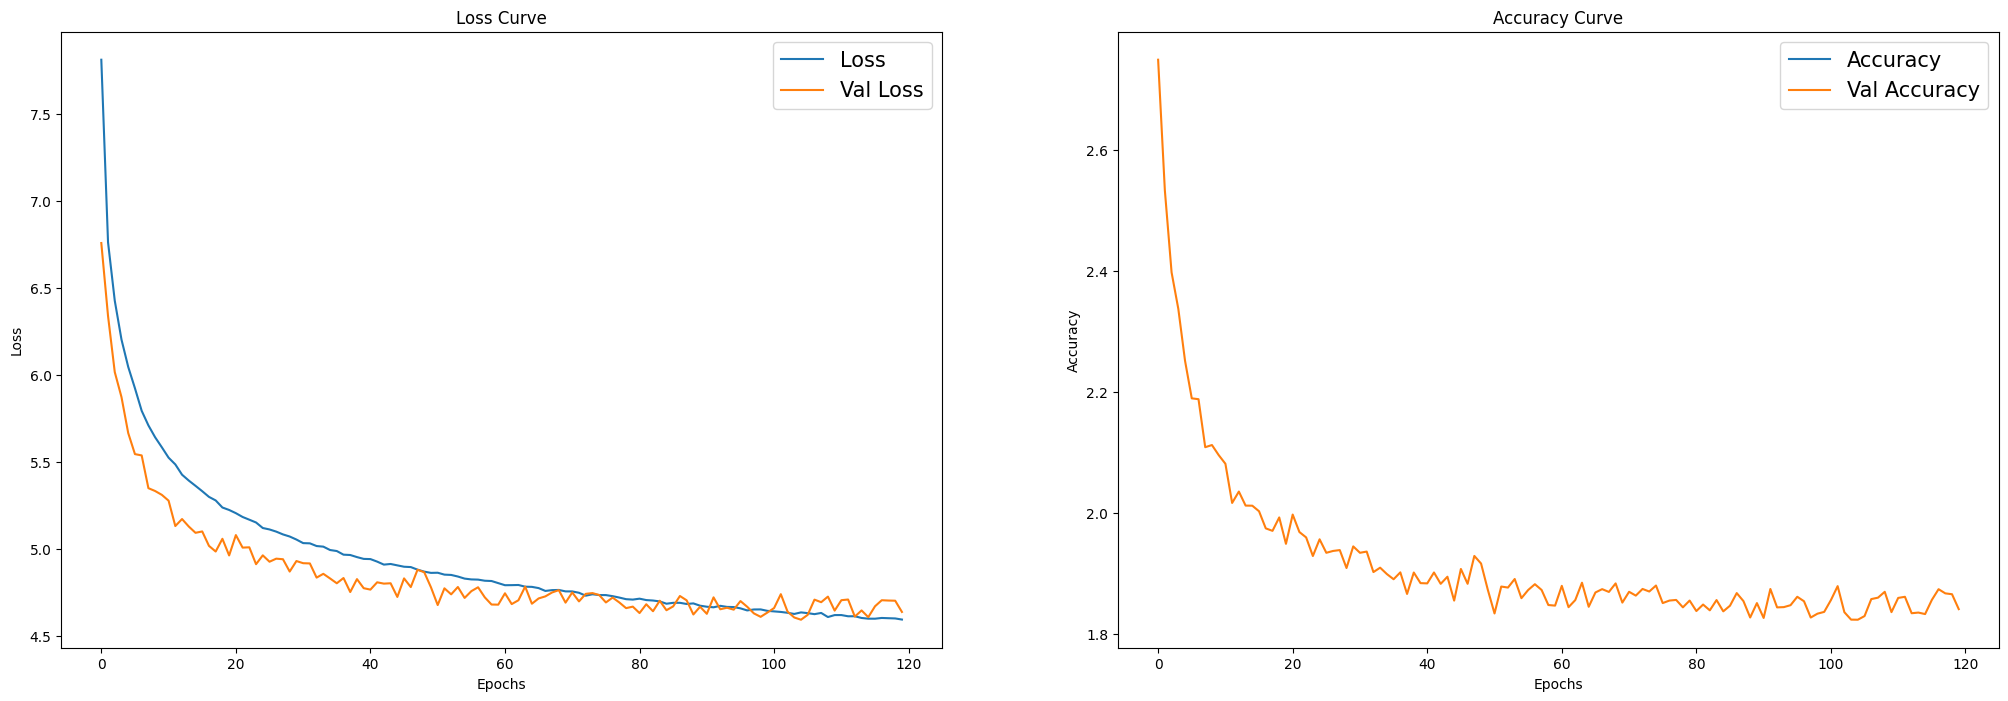

In [44]:
plot_graph(history=stepwise_logger)

KeyError: 'accuracy'

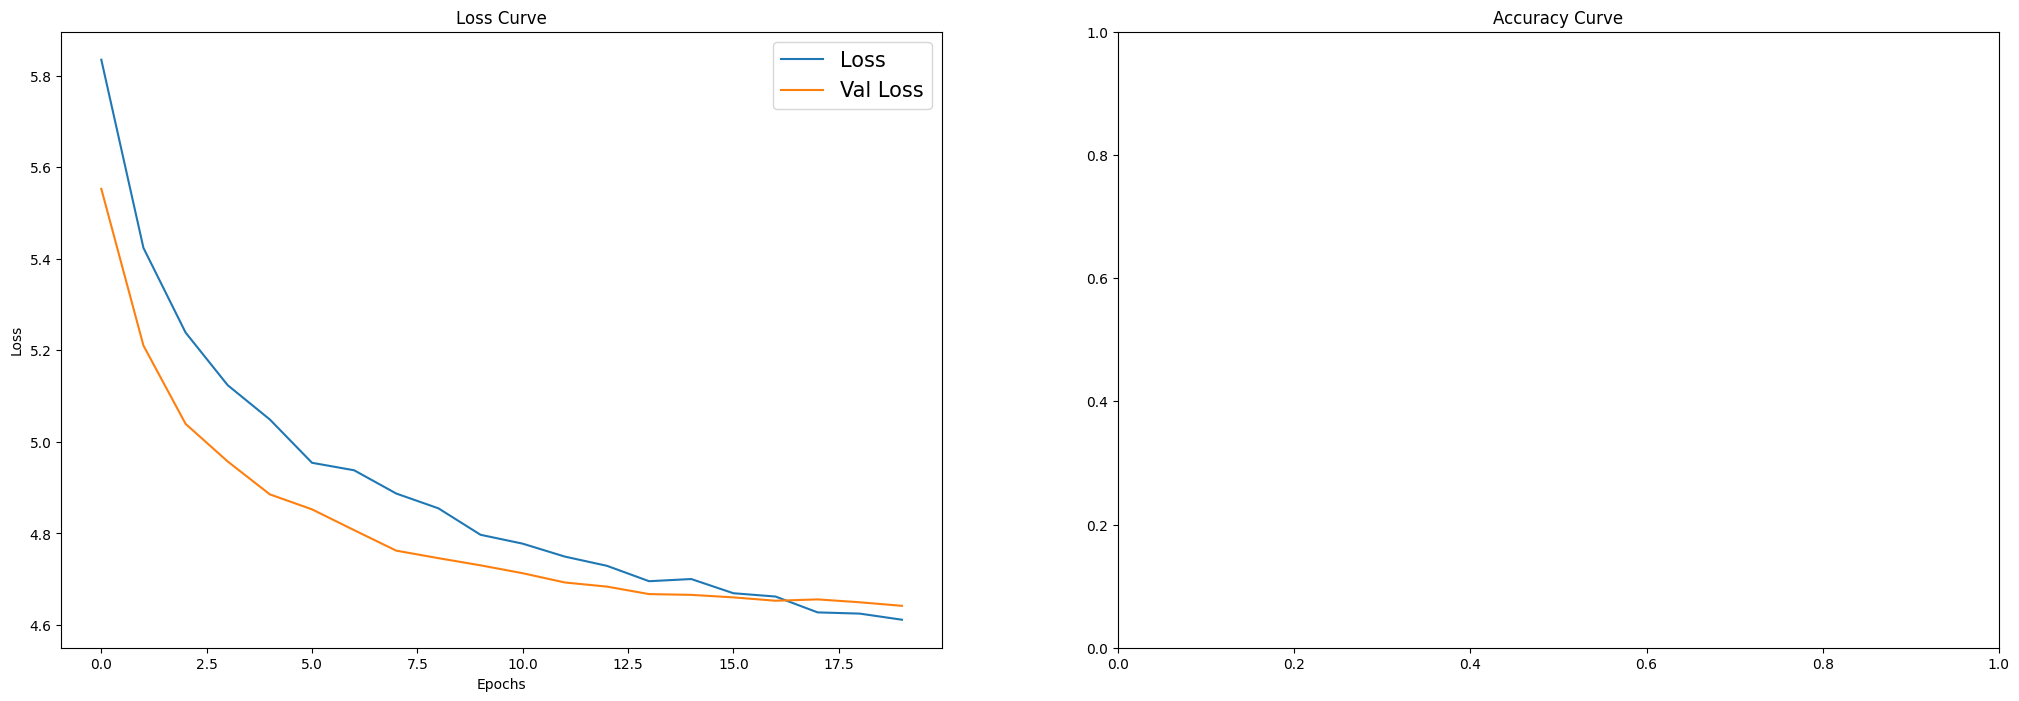

In [45]:
plot_graph(history=history)

In [46]:
model4.evaluate(test_data_generator)

7544/7544 [==============================] - 116s 14ms/step - loss: 4.6391 - full_move_loss: 1.8448 - initial_pos_loss: 1.1902 - final_pos_loss: 1.6041 - full_move_accuracy: 0.4536 - initial_pos_accuracy: 0.5726 - final_pos_accuracy: 0.4877


[4.63909387588501,
 1.8447636365890503,
 1.1902111768722534,
 1.6041181087493896,
 0.4535772502422333,
 0.5725756883621216,
 0.48773127794265747]

In [47]:
model4.save(MODEL_PATH)

In [48]:
with open(HISTORY_PATH, 'w') as file:
    json.dump(history.history, file)

with open(STEP_PATH, 'w') as file:
    json.dump(stepwise_logger.history, file)